# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

import matplotlib.pyplot as plt

# Auxiliary python functions
import time

# Local imports
from moments.bloch import compute_pauli_basis, compute_tensor_basis, compute_subset_index_map, compute_bloch_norms_from_dm
from moments.initialization import (compute_param_from_X, compute_X_from_param, compute_dm_from_X, compute_initial_param_repeat)

# Parametrization of the density matrix

## Non-Cholesky case

In [2]:
d = 2

X = np.random.randn(d, d) + 1j * np.random.randn(d, d)
x = compute_param_from_X(X)
X_rec = compute_X_from_param(x)

print("Parameter vector is real:", np.isreal(x).all())
print("Parameter vector has appropriate dimension:", x.shape[0] == 2 * d**2)


print("\nParameter matrix is complex:", np.iscomplex(X).all())
print("Reconstructec parameter matrix is complex:", np.iscomplex(X_rec).all())
print("Reconstructec parameter matrix has appropriate dimension:", X_rec.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(X, X_rec).all())

Parameter vector is real: True
Parameter vector has appropriate dimension: True

Parameter matrix is complex: True
Reconstructec parameter matrix is complex: True
Reconstructec parameter matrix has appropriate dimension: True

One way reconstruction works: True


In [3]:
x = np.random.randn(2 * d**2)
X = compute_X_from_param(x)
x_rec = compute_param_from_X(X)

print("Parameter vector is real:", np.isreal(x).all())
print("Reconstructed parameter vector is real:", np.isreal(x_rec).all())
print("Reconstructed parameter vector has appropriate dimension:", x_rec.shape[0] == 2 * d**2)

print("\nParameter matrix is complex:", np.iscomplex(X).all())
print("Parameter matrix has appropriate dimension:", X.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(x, x_rec).all())

Parameter vector is real: True
Reconstructed parameter vector is real: True
Reconstructed parameter vector has appropriate dimension: True

Parameter matrix is complex: True
Parameter matrix has appropriate dimension: True

One way reconstruction works: True


## Cholesky case

In [4]:
d = 4

X = np.random.randn(d, d) + 1j * np.random.randn(d, d)
X = np.tril(X)
x = compute_param_from_X(X, cholesky=True)
X_rec = compute_X_from_param(x, cholesky=True)

print("Parameter vector is real:", np.isreal(x).all())
print("Parameter vector has appropriate dimension:", x.shape[0] == d * (d + 1))

print("\nParameter matrix is lower triangular:", np.allclose(X, np.tril(X)))
print("Reconstructed parameter matrix is lower triangular:", np.allclose(X_rec, np.tril(X_rec)))

print("\nParameter matrix is complex:", np.logical_or(np.iscomplex(X), np.isclose(X, np.zeros_like(X))).all())
print("Reconstructed parameter matrix is complex:", np.logical_or(np.iscomplex(X_rec), np.isclose(X_rec, np.zeros_like(X_rec))).all())
print("Reconstructed parameter matrix has appropriate dimension:", X_rec.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(X, X_rec).all())

Parameter vector is real: True
Parameter vector has appropriate dimension: True

Parameter matrix is lower triangular: True
Reconstructed parameter matrix is lower triangular: True

Parameter matrix is complex: True
Reconstructed parameter matrix is complex: True
Reconstructed parameter matrix has appropriate dimension: True

One way reconstruction works: True


In [5]:
x = np.random.randn(d * (d + 1))
X = compute_X_from_param(x, cholesky=True)
x_rec = compute_param_from_X(X, cholesky=True)

print("Parameter vector is real:", np.isreal(x).all())
print("Reconstructed parameter vector is real:", np.isreal(x_rec).all())
print("Reconstructed parameter vector has appropriate dimension:", x_rec.shape[0] == d * (d + 1))

print("\nParameter matrix is complex:", np.logical_or(np.iscomplex(X), np.isclose(X, np.zeros_like(X))).all())
print("Parameter matrix has appropriate dimension:", X.shape == (d, d))

print("\nOne way reconstruction works:", np.isclose(x, x_rec).all())

Parameter vector is real: True
Reconstructed parameter vector is real: True
Reconstructed parameter vector has appropriate dimension: True

Parameter matrix is complex: True
Parameter matrix has appropriate dimension: True

One way reconstruction works: True


# Optimization functions

## Space definition and discretization

In [6]:
N = 2
d = 2 ** N

pauli_basis = compute_pauli_basis()
local_bases = [pauli_basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

In [7]:
D = 20
Dx, Dy, Dz = D + 1, D + 1, int(np.sqrt(3) * D) + 1

x = np.linspace(0, 1, Dx)
y = np.linspace(0, 1, Dy)
z = np.linspace(0, np.sqrt(3), Dz)

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

mask1 = Z >= X + Y - 1
mask2 = Z**2 <= 3 + X**2 + Y**2 - 4*X*Y - 4*np.abs(X - Y)
mask = mask1 & mask2

points = np.column_stack((X[mask], Y[mask], Z[mask]))
total_points = points.shape[0]
print(f"Number of points: {total_points}")

Number of points: 7910


## Optimization non-Cholesky

In [8]:
solutions, R_list, R_app = [], [], []
times, success = [], []

for counter, (x_val, y_val, z_val) in enumerate(points, 1):
    t0 = time.time()
    
    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}
    
    param_res = compute_initial_param_repeat(d, tensor_basis, subset_index_map, Rt)
    
    tf = time.time()
    times.append(tf - t0)
    R_app.append(param_res.moments)
    R_list.append(Rt)
    success.append(param_res.optimizer_info["success"])
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (7910/7910) | Time for this point: 0.015 s

Done!
Successful optimizations: 7910/7910 | Percentage: 100.00 %
Total time: 0.61 min | Average time per point: 0.005 s


In [ ]:
errors = []
times = np.array(times)
solutions = np.array(solutions)
R_list = np.array(R_list)

for xdx, R in enumerate(R_app):
    e = 0
    for subset in R.keys():
        e += np.abs(R[subset] - R_list[xdx][subset])
    errors.append(e)

errors = np.array(errors)
R_app = np.array(R_app)

print(f'Total time: {np.sum(times)/60:0.2f} min.\n')
print(f'Average error: {np.mean(errors)}.\n')

print(f'Max error: {errors[np.argmax(errors)]}.')
print(f'R_target = {R_list[np.argmax(errors)]}.')
print(f'R_app = {R_app[np.argmax(errors)]}.\n')

print(f'Min error: {errors[np.argmin(errors)]}.')
print(f'R_target = {R_list[np.argmin(errors)]}.')
print(f'R_app = {R_app[np.argmin(errors)]}.')

Total time: 0.61 min.

Average error: 6.117422483394298e-06.

Max error:0.00028879962846029006.
R_target = {(1,): 0.55, (2,): 0.65, (1, 2): 1.375452111892932}.
R_app = {(1,): np.float64(0.5500667664292502), (2,): np.float64(0.6498508567067875), (1, 2): np.float64(1.3753792219869343)}.

Min error:1.1682085243602813e-08.
R_target = {(1,): 0.15000000000000002, (2,): 0.6000000000000001, (1, 2): 0.4075413664867946}.
R_app = {(1,): np.float64(0.15000000183988343), (2,): np.float64(0.6000000021868316), (1, 2): np.float64(0.40754137414216496)}.


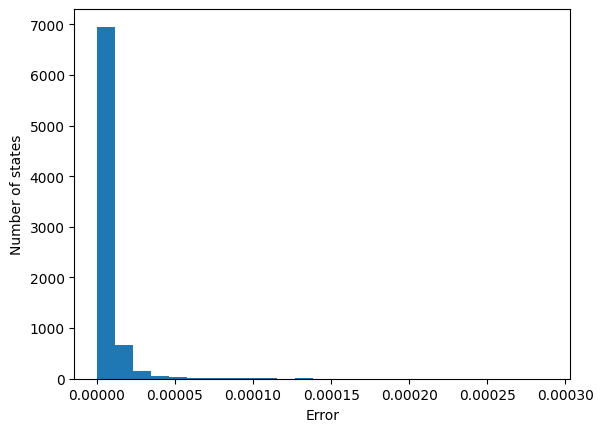

In [10]:
plt.hist(errors, bins=25)
plt.xlabel('Error')
plt.ylabel('Number of states')
plt.show()

## Optimization Cholesky

In [11]:
solutions, R_list, R_app = [], [], []
times, success = [], []

for counter, (x_val, y_val, z_val) in enumerate(points, 1):
    t0 = time.time()
    
    Rt = {(1,): float(x_val), (2,): float(y_val), (1, 2): float(z_val)}
    
    param_res = compute_initial_param_repeat(d, tensor_basis, subset_index_map, Rt, cholesky=True)
    
    tf = time.time()
    times.append(tf - t0)
    R_app.append(param_res.moments)
    R_list.append(Rt)
    success.append(param_res.optimizer_info["success"])
    
    percent_complete = (counter / total_points) * 100
    print(f"\rProgress: {percent_complete:.2f}% ({counter}/{total_points}) | Time for this point: {tf-t0:.3f} s", end="", flush=True)

print(f"\n\nDone!")
print(f"Successful optimizations: {sum(success)}/{total_points} | Percentage: {sum(success)*100/total_points:.2f} %")
print(f"Total time: {sum(times)/60:.2f} min | Average time per point: {sum(times)/total_points:.3f} s", )

Progress: 100.00% (7910/7910) | Time for this point: 0.016 s

Done!
Successful optimizations: 7910/7910 | Percentage: 100.00 %
Total time: 1.15 min | Average time per point: 0.009 s


In [ ]:
errors = []
times = np.array(times)
solutions = np.array(solutions)
R_list = np.array(R_list)

for xdx, R in enumerate(R_app):
    e = 0
    for subset in R.keys():
        e += np.abs(R[subset] - R_list[xdx][subset])
    errors.append(e)

errors = np.array(errors)
R_app = np.array(R_app)

print(f'Total time: {np.sum(times)/60:0.2f} min.\n')
print(f'Average error: {np.mean(errors)}.\n')

print(f'Max error: {errors[np.argmax(errors)]}.')
print(f'R_target = {R_list[np.argmax(errors)]}.')
print(f'R_app = {R_app[np.argmax(errors)]}.\n')

print(f'Min error: {errors[np.argmin(errors)]}.')
print(f'R_target = {R_list[np.argmin(errors)]}.')
print(f'R_app = {R_app[np.argmin(errors)]}.')

Total time: 1.15 min.

Average error: 0.00011371722530865483.

Max error:0.20000000013510605.
R_target = {(1,): 0.30000000000000004, (2,): 0.5, (1, 2): 0.0}.
R_app = {(1,): np.float64(0.36666663447717196), (2,): np.float64(0.5666680969391661), (1, 2): np.float64(0.06666526871876804)}.

Min error:5.738657382625689e-09.
R_target = {(1,): 0.25, (2,): 0.35000000000000003, (1, 2): 0.6622547205410413}.
R_app = {(1,): np.float64(0.250000001011902), (2,): np.float64(0.3499999993991979), (1, 2): np.float64(0.662254716415088)}.


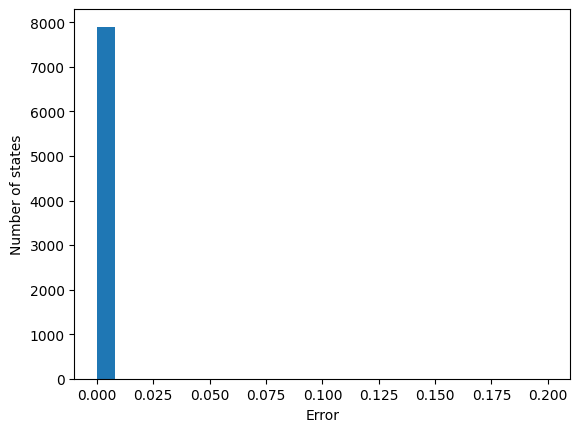

In [13]:
plt.hist(errors, bins=25)
plt.xlabel('Error')
plt.ylabel('Number of states')
plt.show()